In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, PrecisionRecallDisplay, confusion_matrix
from sklearn.multioutput import MultiOutputClassifier
from scipy.stats import entropy

# Styling for plots
plt.style.use('dark_background') # Adjust to your Jupyter theme
sns.set_palette("muted")

train_df = pd.read_csv("data/input/train_split.csv")
val_df = pd.read_csv("data/input/val_split.csv")

train_df['comment_text'] = train_df['comment_text'].fillna("missing")
val_df['comment_text'] = val_df['comment_text'].fillna("missing")

In [2]:
print("Fitting TF-IDF...")
vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))

X_train_vec = vectorizer.fit_transform(train_df['comment_text'])
X_val_vec = vectorizer.transform(val_df['comment_text'])

# We MUST extract the vocabulary to map feature importance later
feature_names = vectorizer.get_feature_names_out().tolist()

y_train_toxic = train_df['toxicity'].values
y_val_toxic = val_df['toxicity'].values

Fitting TF-IDF...


In [3]:
print("Training LightGBM Gatekeeper...")

# Calculate dynamic scale_pos_weight for severe imbalance
pos_weight = len(y_train_toxic[y_train_toxic == 0]) / len(y_train_toxic[y_train_toxic == 1])

lgb_train = lgb.Dataset(X_train_vec, label=y_train_toxic, feature_name=feature_names)
lgb_val = lgb.Dataset(X_val_vec, label=y_val_toxic, feature_name=feature_names, reference=lgb_train)

params = {
    'objective': 'binary',
    'metric': 'average_precision',           # FIX 1: Only track PR-AUC for early stopping
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,            # FIX 2: Reduce leaf count to stop instant memorization
    'min_data_in_leaf': 50,      # FIX 3: Require at least 50 comments per leaf
    'scale_pos_weight': pos_weight, 
    'feature_fraction': 0.8,
    'verbose': 2
}

evals_result = {}
lgb_gatekeeper = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_val],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, first_metric_only=True), # Ensure it uses aucpr
        lgb.record_evaluation(evals_result)
    ]
)

val_probs_lgb = lgb_gatekeeper.predict(X_val_vec)

# We will temporarily use 0.5 for the classification report, 
# but remember we will tune this threshold later!
val_preds_lgb = (val_probs_lgb > 0.5).astype(int)

Training LightGBM Gatekeeper...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 6391, number of negative: 73590
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.996387
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.996092
[LightGBM] [Debug] init for col-wise cost 1.137959 seconds, init for row-wise cost 1.125395 seconds
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.411686 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Sparse Multi-Val Bin
[LightGBM] [Info] Total Bins 935178
[LightGBM] [Info] Number of data points in the train set: 79981, number of used features: 14971
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.079906 -> initscore=-2.4436

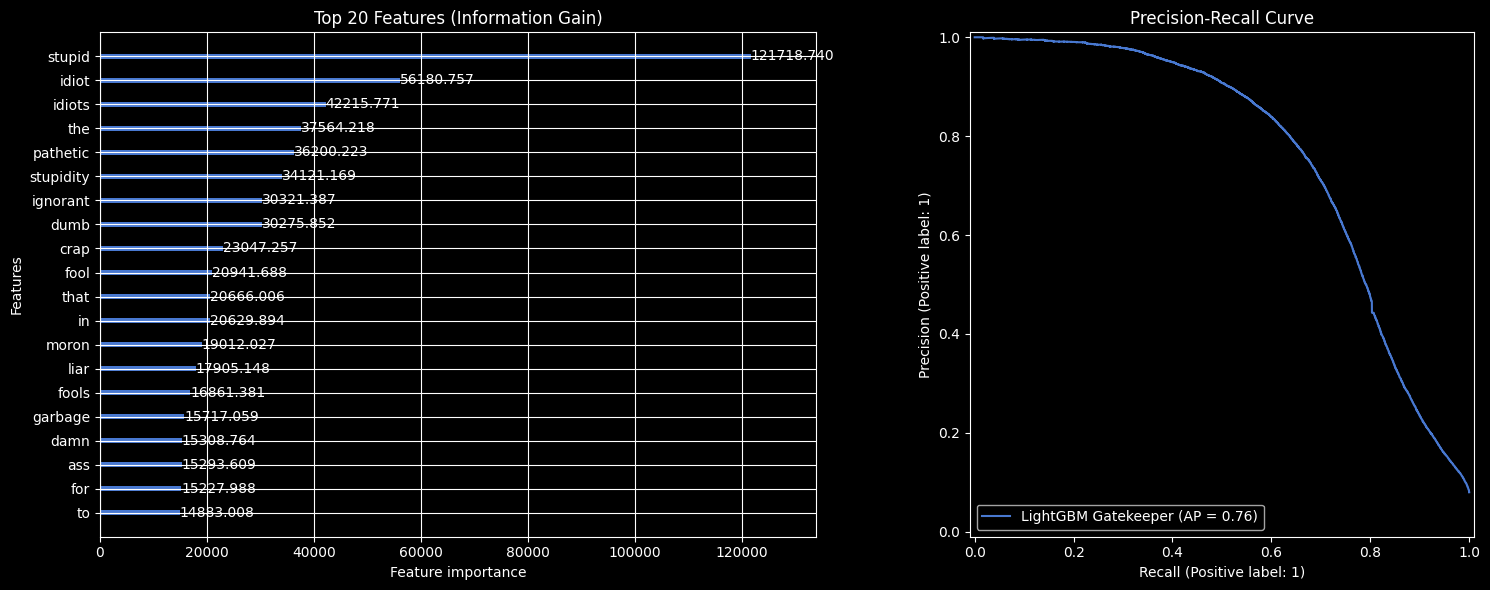


Gatekeeper Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97    294358
           1       0.63      0.74      0.68     25565

    accuracy                           0.94    319923
   macro avg       0.80      0.85      0.82    319923
weighted avg       0.95      0.94      0.95    319923



In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Feature Importance Plot (Top 20 words driving the toxicity prediction)
lgb.plot_importance(lgb_gatekeeper, max_num_features=20, ax=axes[0], importance_type='gain', 
                    title="Top 20 Features (Information Gain)")

# 2. Precision-Recall Curve (Crucial for imbalanced data)
PrecisionRecallDisplay.from_predictions(y_val_toxic, val_probs_lgb, ax=axes[1], name="LightGBM Gatekeeper")
axes[1].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

print("\nGatekeeper Classification Report:")
print(classification_report(y_val_toxic, val_preds_lgb))

In [5]:
print("Extracting Leaf Node Indices and building Meta-Risk features...")

# Extract the leaf path matrix
leaf_indices = lgb_gatekeeper.predict(X_val_vec, pred_leaf=True)

top_probs = np.maximum(val_probs_lgb, 1 - val_probs_lgb)
margins = np.abs(val_probs_lgb - (1 - val_probs_lgb))
entropies = entropy(np.vstack((val_probs_lgb, 1 - val_probs_lgb)).T, base=2, axis=1)

# Combine textual structural data (leaves) with confidence metrics
risk_features = pd.DataFrame(leaf_indices, columns=[f'tree_{i}' for i in range(leaf_indices.shape[1])])
risk_features['confidence'] = top_probs
risk_features['margin'] = margins
risk_features['entropy'] = entropies

gatekeeper_errors = (val_preds_lgb != y_val_toxic).astype(int)

print("Training XGBoost Meta-Risk Classifier...")
risk_model = xgb.XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.05, 
                               scale_pos_weight=len(gatekeeper_errors[gatekeeper_errors==0])/len(gatekeeper_errors[gatekeeper_errors==1]))
risk_model.fit(risk_features, gatekeeper_errors)

risk_preds = risk_model.predict(risk_features)
print(classification_report(gatekeeper_errors, risk_preds))

Extracting Leaf Node Indices and building Meta-Risk features...
Training XGBoost Meta-Risk Classifier...
              precision    recall  f1-score   support

           0       0.99      0.86      0.92    302015
           1       0.26      0.82      0.39     17908

    accuracy                           0.86    319923
   macro avg       0.62      0.84      0.66    319923
weighted avg       0.95      0.86      0.89    319923



Loading and preparing Test Data...
Evaluating Gatekeeper on Test Data...

Confusion Matrix (Test Data):
[[1432402   39384]
 [  69500   58326]]


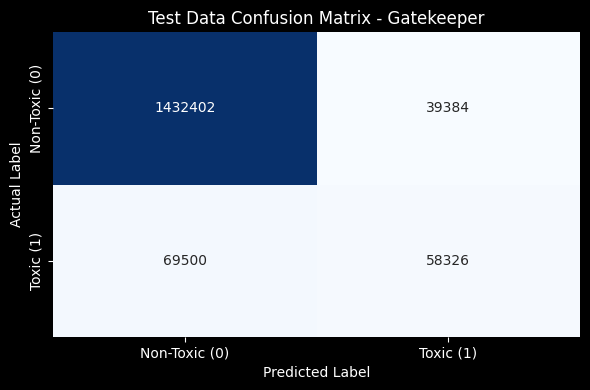

In [7]:
# %%
print("Loading and preparing Test Data...")
test_df = pd.read_csv("data/input/test_split.csv")
test_df['comment_text'] = test_df['comment_text'].fillna("missing")

# Transform test text using the already fitted TF-IDF vectorizer
X_test_vec = vectorizer.transform(test_df['comment_text'])
y_test_toxic = test_df['toxicity'].values

# %%
print("Evaluating Gatekeeper on Test Data...")
# Predict probability of toxicity for the test set
test_probs_lgb = lgb_gatekeeper.predict(X_test_vec)

# Convert probabilities to binary predictions (using 0.5 threshold)
test_preds_lgb = (test_probs_lgb > 0.5).astype(int)

# Generate the confusion matrix
cm = confusion_matrix(y_test_toxic, test_preds_lgb)

print("\nConfusion Matrix (Test Data):")
print(cm)

# Create a nice visual plot of the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Toxic (0)', 'Toxic (1)'], 
            yticklabels=['Non-Toxic (0)', 'Toxic (1)'])
plt.title('Test Data Confusion Matrix - Gatekeeper')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# You can stop here for now!

Generating Precision, Recall, and F1 curves across thresholds...


C:\Users\priya\AppData\Local\Temp\ipykernel_19512\530188821.py:43: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\priya\anaconda3\envs\toxicity\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


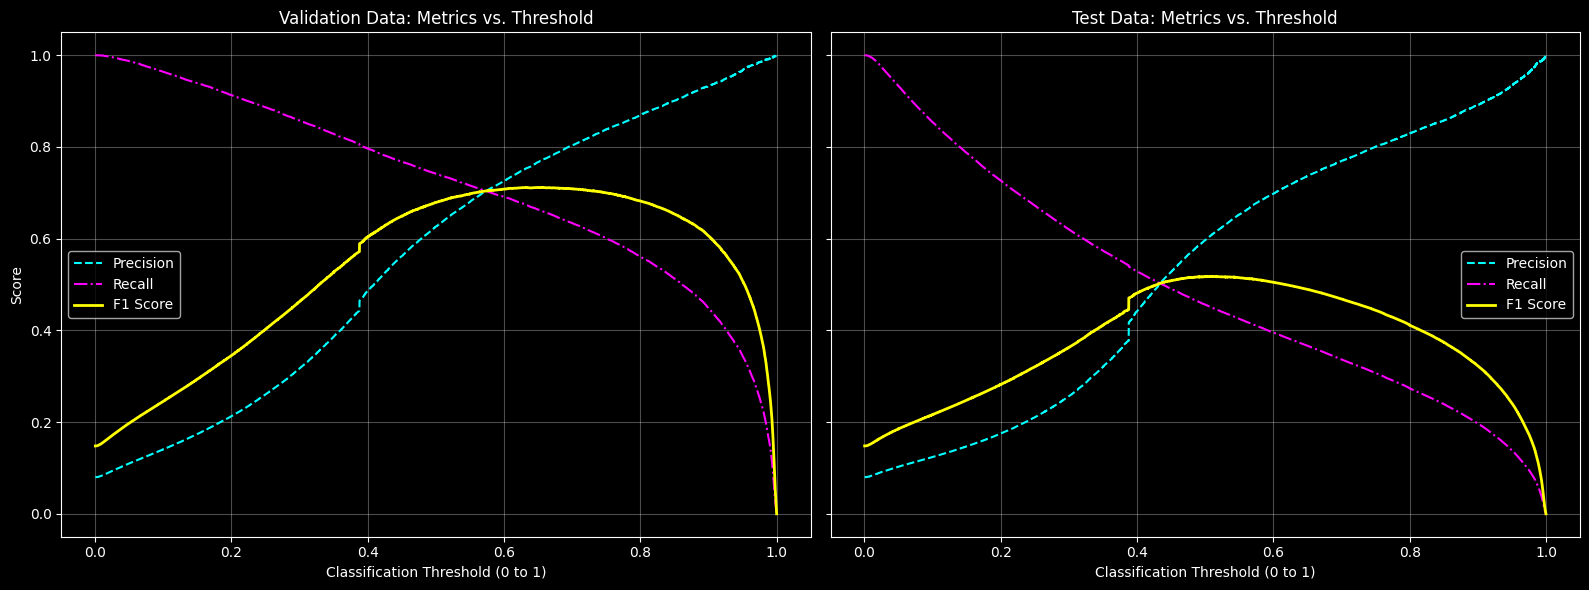

Optimal Threshold for Validation (Max F1): 0.6529 (F1: 0.7117)


In [8]:
# %%
from sklearn.metrics import precision_recall_curve
import numpy as np

print("Generating Precision, Recall, and F1 curves across thresholds...")

# --- Validation Data Metrics ---
precision_val, recall_val, thresholds_val = precision_recall_curve(y_val_toxic, val_probs_lgb)
# Calculate F1 score (handling potential division by zero at extreme thresholds)
f1_val = np.divide(2 * precision_val * recall_val, (precision_val + recall_val), 
                   out=np.zeros_like(precision_val), where=(precision_val + recall_val) != 0)

# --- Test Data Metrics ---
precision_test, recall_test, thresholds_test = precision_recall_curve(y_test_toxic, test_probs_lgb)
f1_test = np.divide(2 * precision_test * recall_test, (precision_test + recall_test), 
                    out=np.zeros_like(precision_test), where=(precision_test + recall_test) != 0)

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Note: precision_recall_curve returns one more value for precision/recall than thresholds, 
# so we slice them using [:-1] to match the length of the thresholds array for plotting.

# 1. Validation Curves
axes[0].plot(thresholds_val, precision_val[:-1], label='Precision', color='cyan', linestyle='--')
axes[0].plot(thresholds_val, recall_val[:-1], label='Recall', color='magenta', linestyle='-.')
axes[0].plot(thresholds_val, f1_val[:-1], label='F1 Score', color='yellow', linewidth=2)
axes[0].set_title('Validation Data: Metrics vs. Threshold')
axes[0].set_xlabel('Classification Threshold (0 to 1)')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Test Curves
axes[1].plot(thresholds_test, precision_test[:-1], label='Precision', color='cyan', linestyle='--')
axes[1].plot(thresholds_test, recall_test[:-1], label='Recall', color='magenta', linestyle='-.')
axes[1].plot(thresholds_test, f1_test[:-1], label='F1 Score', color='yellow', linewidth=2)
axes[1].set_title('Test Data: Metrics vs. Threshold')
axes[1].set_xlabel('Classification Threshold (0 to 1)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Optional: Find the optimal threshold that maximizes the F1 score on Validation data
best_idx = np.argmax(f1_val)
best_threshold = thresholds_val[best_idx]
print(f"Optimal Threshold for Validation (Max F1): {best_threshold:.4f} (F1: {f1_val[best_idx]:.4f})")